In [1]:
import cogsworth
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astropy.units as u

import gala.potential as gp
import gala.dynamics as gd
from gala.units import galactic

In [2]:
# this all just makes plots look nice
%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)
pd.options.display.max_columns = 999

In [3]:
static_nfw = gp.NFWPotential(m=1e12 * u.Msun, r_s=10 * u.kpc, units=galactic)
static_nfw

<NFWPotential: m=1.00e+12 solMass, r_s=10.00 kpc, a=1.00 , b=1.00 , c=1.00  (kpc,Myr,solMass,rad)>

In [4]:
time_knots = np.linspace(0, 12, 20) * u.Gyr
masses = np.linspace(1e11, 1e12, 20) * u.Msun
evolving_nfw = gp.TimeInterpolatedPotential(
    gp.NFWPotential, time_knots, m=masses, r_s=10 * u.kpc, units=galactic
)
evolving_nfw

<TimeInterpolatedPotential: NFWPotential interpolation_method='cspline')>

In [5]:
w0 = gd.PhaseSpacePosition(
    pos=[8, 0, 0] * u.kpc,
    vel=[50, 50, -5] * u.km / u.s
)
w0

<PhaseSpacePosition cartesian, dim=3, shape=()>

In [6]:
orbits = [
    pot.integrate_orbit(w0, t1=0 * u.Gyr, t2=12 * u.Gyr, dt=1 * u.Myr, Integrator="DOPRI853")
    for pot in (static_nfw, evolving_nfw)
]

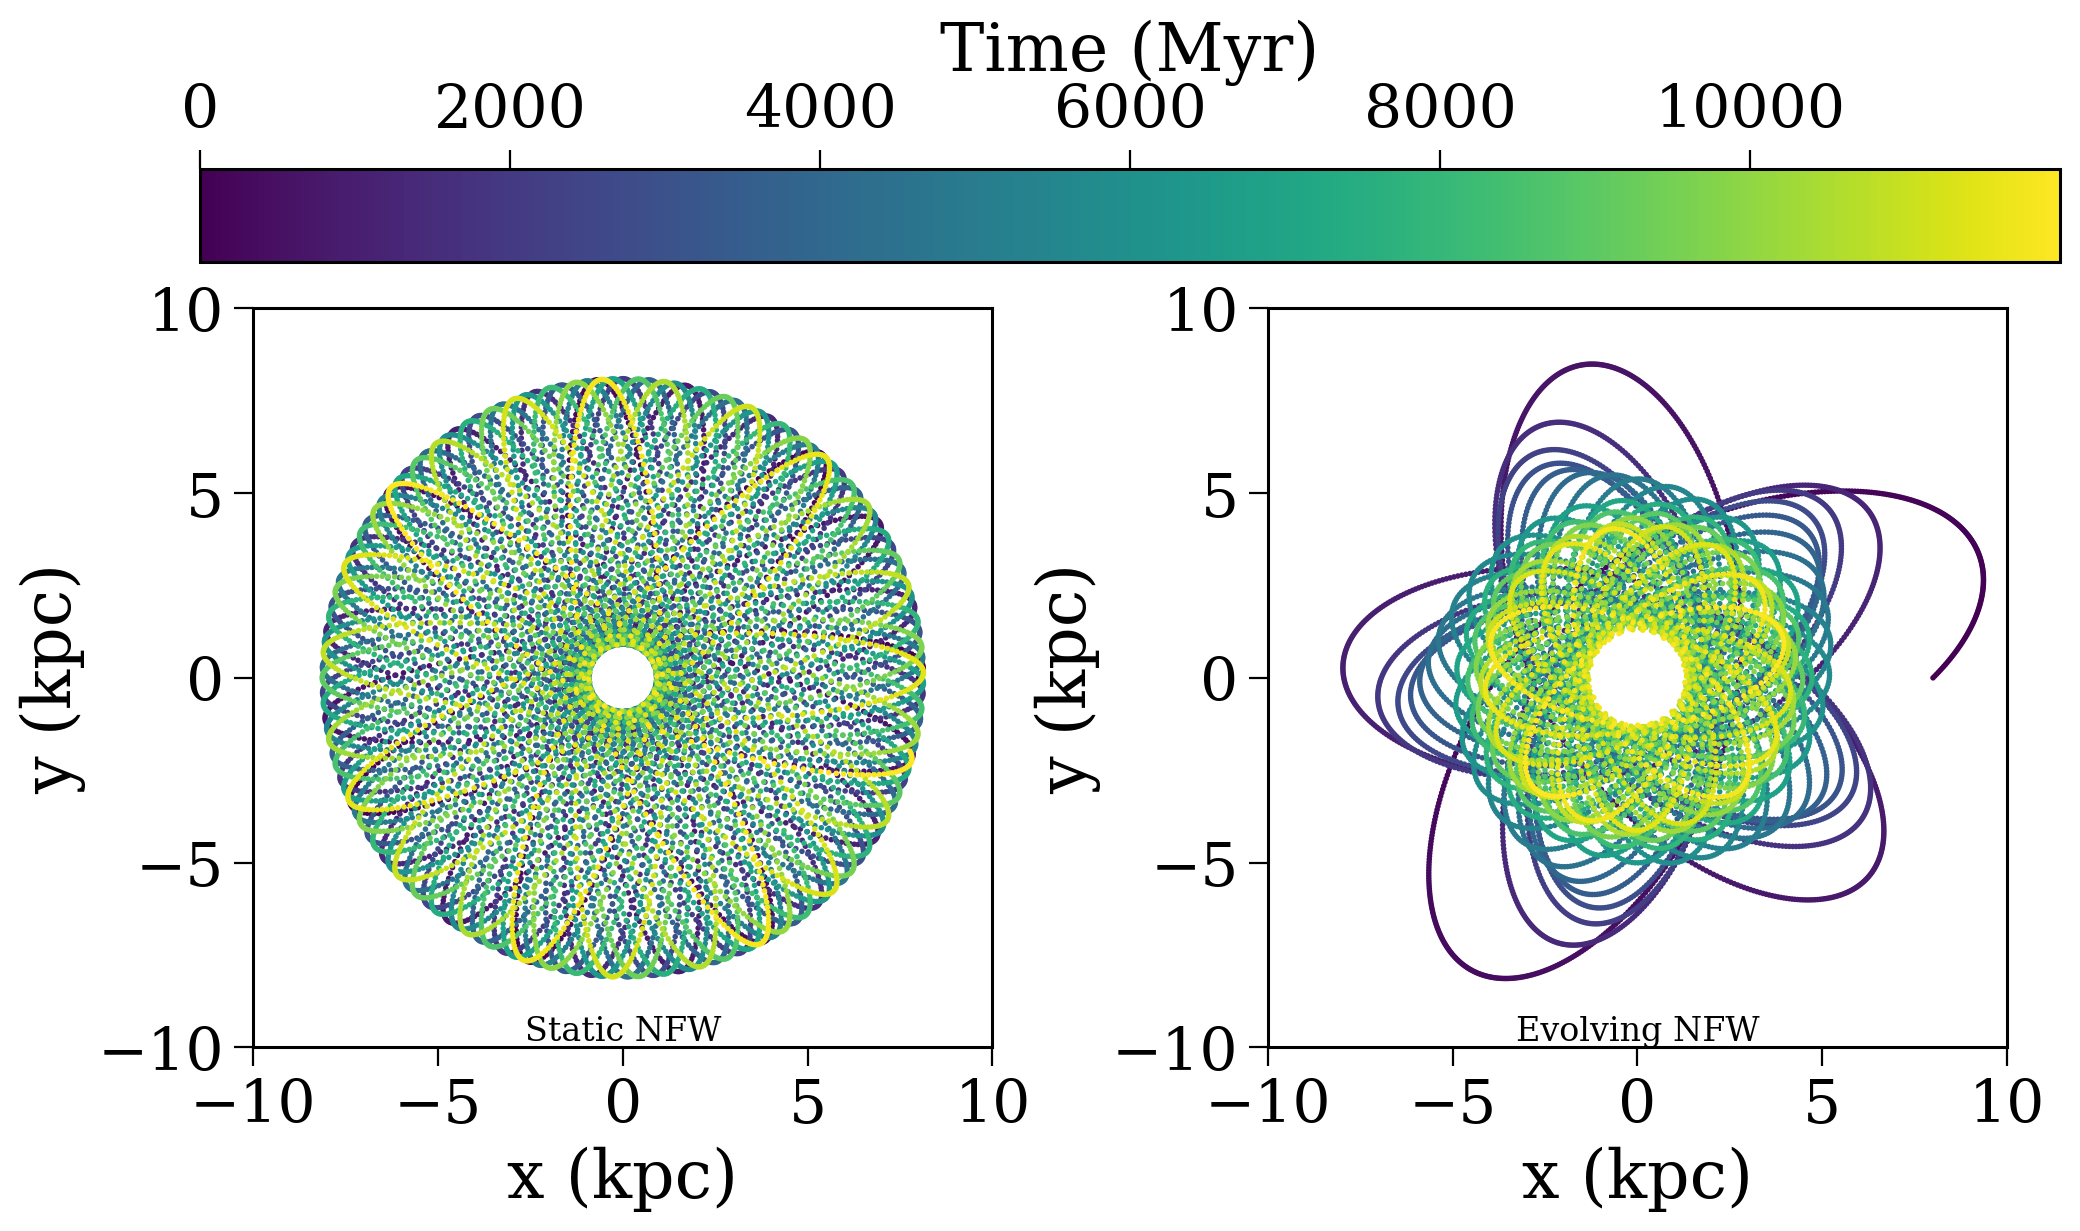

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for orbit, ax in zip(orbits, axes):
    scatter = ax.scatter(orbit.x, orbit.y, c=orbit.t.value, s=1)
    ax.annotate("Evolving NFW" if ax == axes[1] else "Static NFW", xy=(0.5, 0.0), xycoords='axes fraction',
                fontsize=12, ha='center', va='bottom')
    ax.set_aspect('equal')
    ax.set(
        xlim=(-10, 10),
        ylim=(-10, 10),
        xlabel='x (kpc)',
        ylabel='y (kpc)',
    )

fig.colorbar(scatter, ax=axes, label='Time (Myr)', orientation='horizontal', location="top")

plt.show()    

In [9]:
p = cogsworth.pop.Population(100, galactic_potential=evolving_nfw, use_default_BSE_settings=True)
p.create_population()

Run for 100 binaries
Sampled 131 binaries
[5e-03s] Sample initial binaries
[0.1s] Evolve binaries (run COSMIC)


Integrating orbits: 100%|██████████| 131/131 [00:00<00:00, 1524.37it/s]


[0.4s] Integrate galactic orbits (run gala)
Overall: 0.5s


In [20]:
time_knots = np.linspace(0, 12, 5) * u.Gyr
mass_fractions = np.linspace(0.1, 1.0, 5)

evolving_mw = gp.CCompositePotential(
    disk=gp.TimeInterpolatedPotential(
        gp.MN3ExponentialDiskPotential,
        time_knots,
        m=6.8e10 * u.Msun * mass_fractions,
        h_R=2.6 * u.kpc,
        h_z=0.3 * u.kpc,
        units="galactic"
    ),
    bulge=gp.TimeInterpolatedPotential(
        gp.HernquistPotential,
        time_knots,
        m=5e9 * u.Msun * mass_fractions,
        c=1.0 * u.kpc,
        units="galactic"
    ),
    nucleus=gp.TimeInterpolatedPotential(
        gp.HernquistPotential,
        time_knots,
        m=1.81e9 * u.Msun * mass_fractions,
        c=0.07 * u.kpc,
        units="galactic"
    ),
    halo= gp.TimeInterpolatedPotential(
        gp.NFWPotential,
        time_knots,
        m=5.4e11 * u.Msun * mass_fractions,
        r_s=15.63 * u.kpc,
        units="galactic"
    )
)

In [22]:
pop_static = cogsworth.pop.Population(
    2500, final_kstar1=[13, 14],
    galactic_potential=gp.MilkyWayPotential(version='v2'),
    use_default_BSE_settings=True
)
pop_static.create_population()

Run for 2500 binaries
Sampled 2549 binaries
[3e-02s] Sample initial binaries
[3.0s] Evolve binaries (run COSMIC)


Integrating orbits: 100%|██████████| 2741/2741 [00:03<00:00, 727.59it/s] 
cogsworth warning: 3 orbit(s) failed numerical integration, removing them. This can occur due to NaNs in stellar evolution or extreme orbits (e.g. passing directly through the galactic centre) that Gala cannot handle. Information for these systems was saved to `./failed_integration_binaries_1.h5`. This includes their initial_binaries, bpp, kick_info, and initial galaxy objects.


[4.8s] Integrate galactic orbits (run gala)
Overall: 7.8s


In [23]:
pop_evolving = pop_static.copy()
pop_evolving.galactic_potential = evolving_mw
pop_evolving.perform_galactic_evolution()

Integrating orbits: 100%|██████████| 2738/2738 [00:26<00:00, 101.52it/s]


Now we have the exact same binaries evolved in a different potential. Let's look at how things changed for the NSs and BHs.

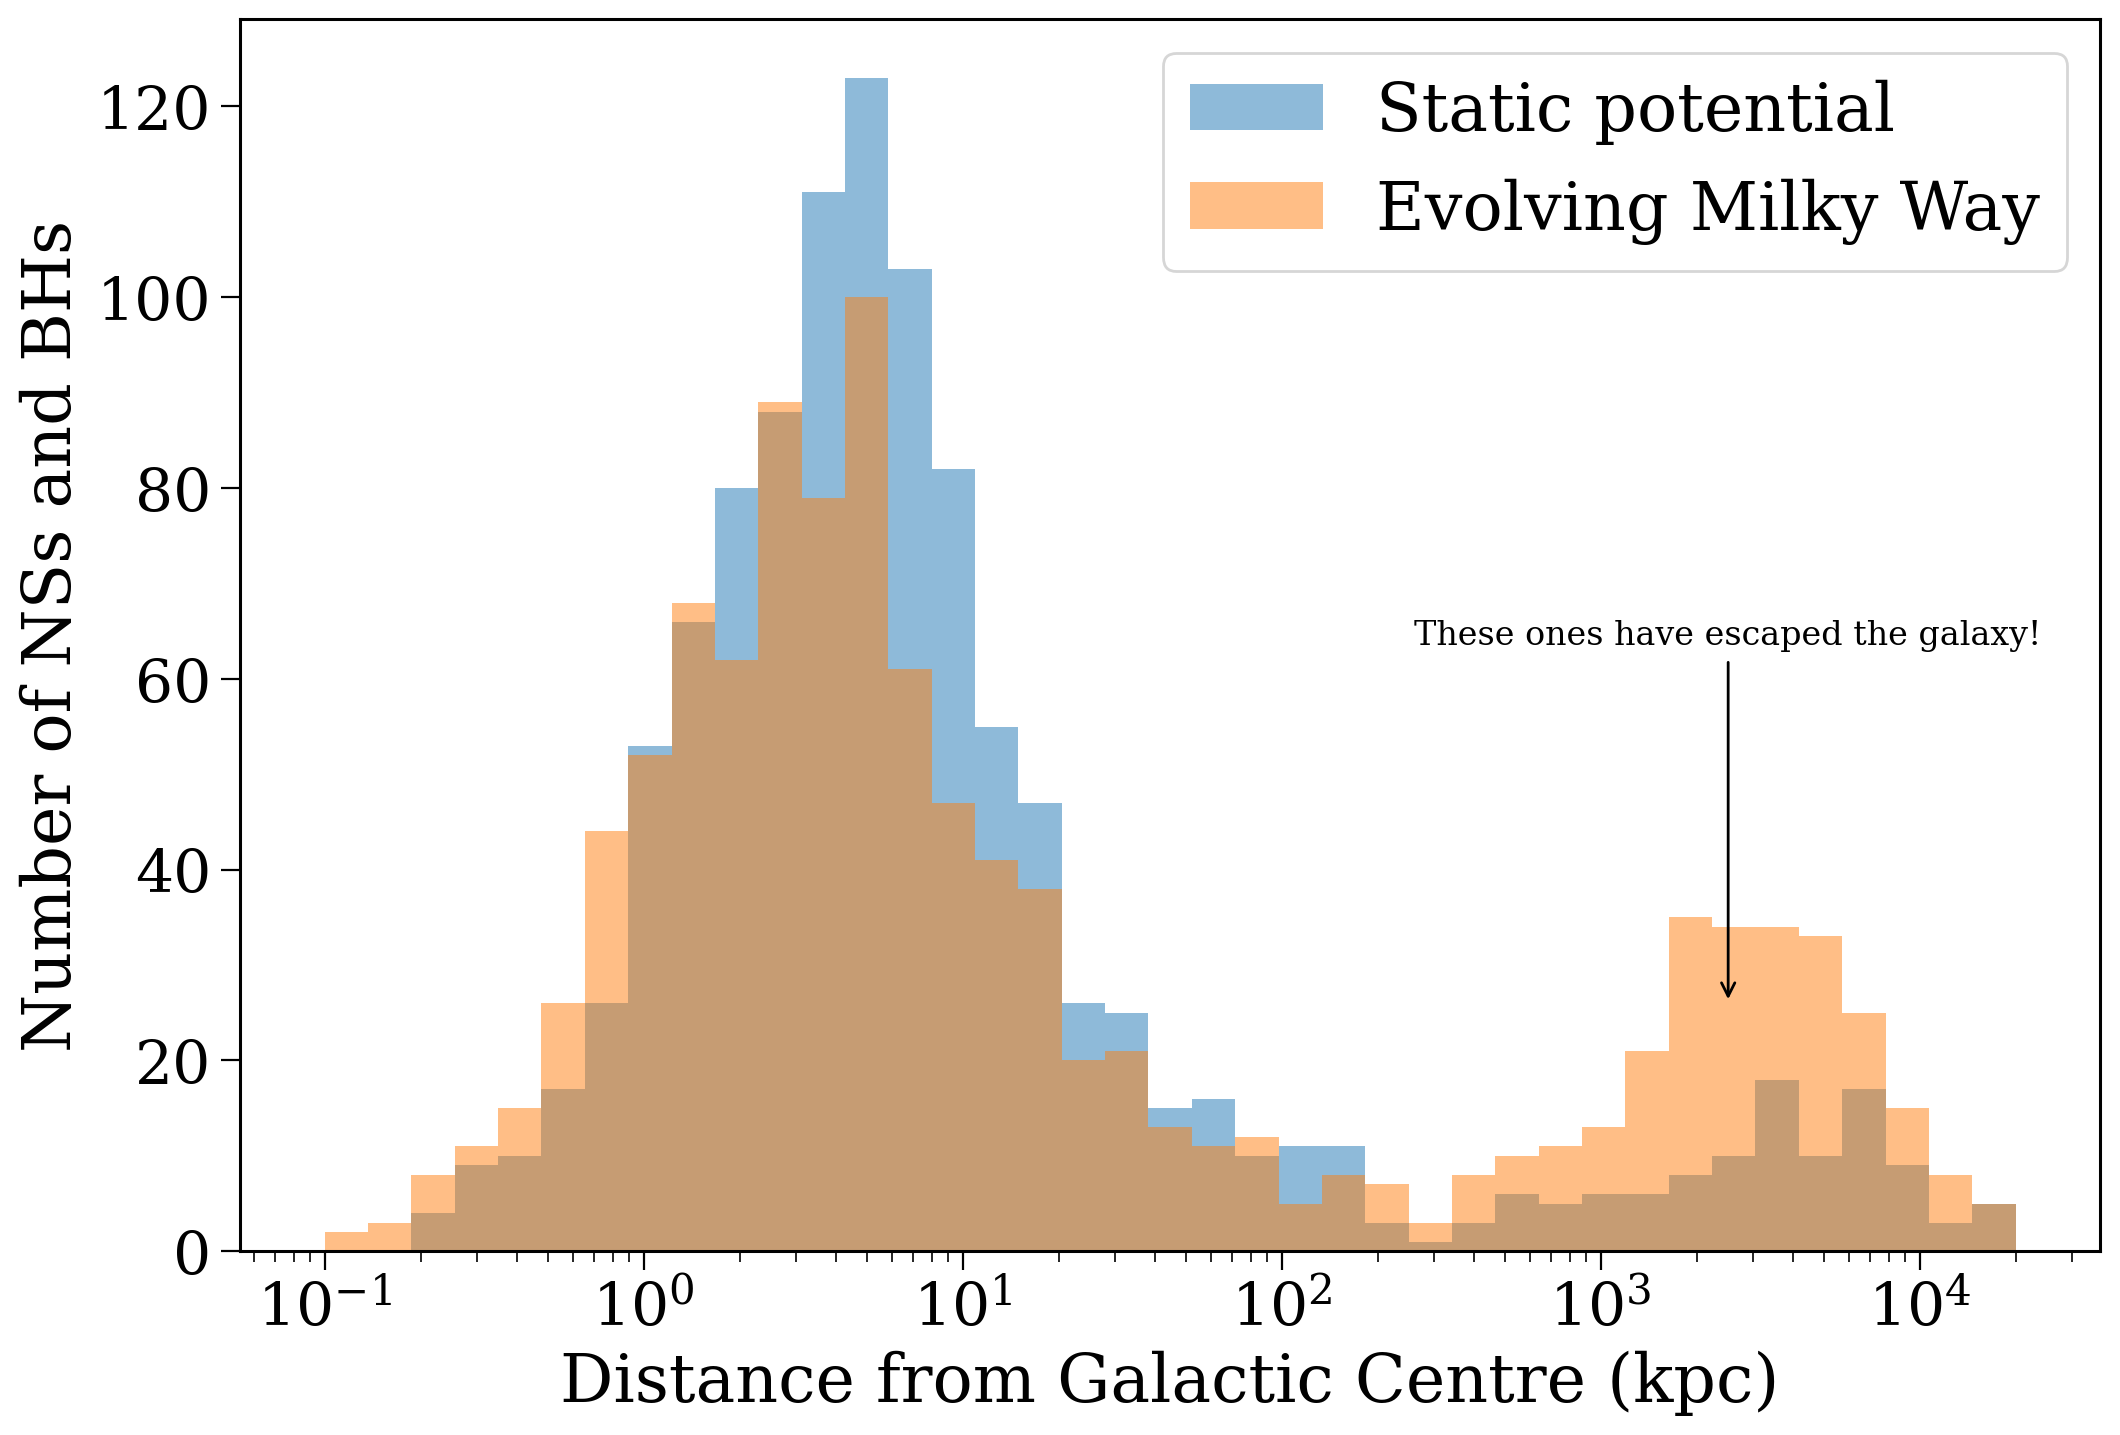

In [33]:
# we can use the static pop to mask both since the stellar evolution is the same in both
primary_NS_or_BH = pop_static.final_bpp["kstar_1"].isin([13, 14])
secondary_NS_or_BH = pop_static.final_bpp["kstar_2"].isin([13, 14])

# plot the distance from the galactic centre for the NSs and BHs in each population
fig, ax = plt.subplots()
for pop, label, c in zip((pop_static, pop_evolving), ("Static potential", "Evolving Milky Way"), ("C0", "C1")):
    distances = np.concatenate([np.linalg.norm(pop.final_primary_pos[primary_NS_or_BH], axis=1),
                                np.linalg.norm(pop.final_secondary_pos[secondary_NS_or_BH], axis=1)])
    ax.hist(distances.to(u.kpc).value, bins=np.geomspace(0.1, 2e4, 40), alpha=0.5, label=label, color=c)

ax.annotate("These ones have escaped the galaxy!", xy=(0.8, 0.2), xytext=(0.8, 0.5),
            arrowprops=dict(arrowstyle="->", color='k'),
            xycoords='axes fraction', fontsize=12, ha='center', va='center')

ax.set(
    xscale='log',
    xlabel='Distance from Galactic Centre (kpc)',
    ylabel='Number of NSs and BHs',
)

ax.legend()

plt.show()

So what do we see? It looks like accounting for the fact that the Milky Way was less massive in its earlier years (we all put on weight in later life, don't worry MW) means that more compact objects escape the galaxy! The BHs and NSs receive the same kicks in both cases, but the weaker potential in early times can allow more to escape!